# Лабораторна робота №4: Інтерактивна візуалізація та цифрова фільтрація сигналів

## Хід виконання роботи
1. **Реалізувати програму** для генерації гармонічного сигналу виду $y(t) = A \cdot \sin(\omega t + \phi)$ із можливістю накладання гаусового шуму з налаштовуваним математичним сподіванням ($\mu$) та дисперсією ($\sigma^2$).
2. **Створити інтерактивний інтерфейс** на базі `matplotlib.widgets` (слайдери для параметрів гармоніки та шуму, чекбокс відображення, кнопка скидання параметрів).
3. **Забезпечити оптимізацію генерації шуму:** при зміні параметрів сигналу сам шум не повинен перегенеровуватись наново; при зміні параметрів шуму — сигнал залишається незмінним.
4. **Реалізувати цифровий фільтр** (застосовано низькочастотний фільтр Баттерворта 4-го порядку з бібліотеки `scipy.signal`) для очищення сигналу та порівняти відфільтровану гармоніку з початковою «чистою».
5. **Додати інтерактивну інструкцію** користувача безпосередньо у вікно інтерфейсу.

### Етап 1: Імпорт бібліотек, генерація сигналу та фільтрація
У цьому блоці реалізовано функцію `harmonic_with_noise` для розрахунку точок сигналу, а також функцію `filter_signal`, яка будує коефіцієнти фільтра за допомогою `iirfilter` та застосовує їх через лінійну цифрову фільтрацію `lfilter`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import iirfilter, lfilter

def harmonic_with_noise(amplitude, frequency, phase, noise_mean, noise_covariance, show_noise=True, global_noise=None):
    t = np.linspace(0, 10, 1000)
    omega = 2 * np.pi * frequency
    y_pure = amplitude * np.sin(omega * t + phase)
    
    if global_noise is None:
        std_dev = np.sqrt(noise_covariance)
        noise = np.random.normal(noise_mean, std_dev, size=len(t))
    else:
        noise = global_noise
        
    y_noisy = y_pure + noise if show_noise else y_pure
    return t, y_pure, y_noisy, noise

def filter_signal(data, cutoff, fs=100.0):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    if normal_cutoff >= 1.0:
        normal_cutoff = 0.99
    # Використовуємо низькочастотний фільтр Баттерворта (Butterworth) 4-го порядку
    b, a = iirfilter(4, normal_cutoff, btype='low', ftype='butter')
    return lfilter(b, a, data)

### Етап 2: Ініціалізація інтерфейсу, побудова графіків та логіка інтерактивних елементів
Створення головного вікна програми. Налаштування віджетів `Slider`, `Button`, `CheckButtons`. Реалізація функцій зворотного виклику (callbacks) `update` та `reset_sliders` для миттєвого перемальовування шарів без перезапуску всього скрипта.

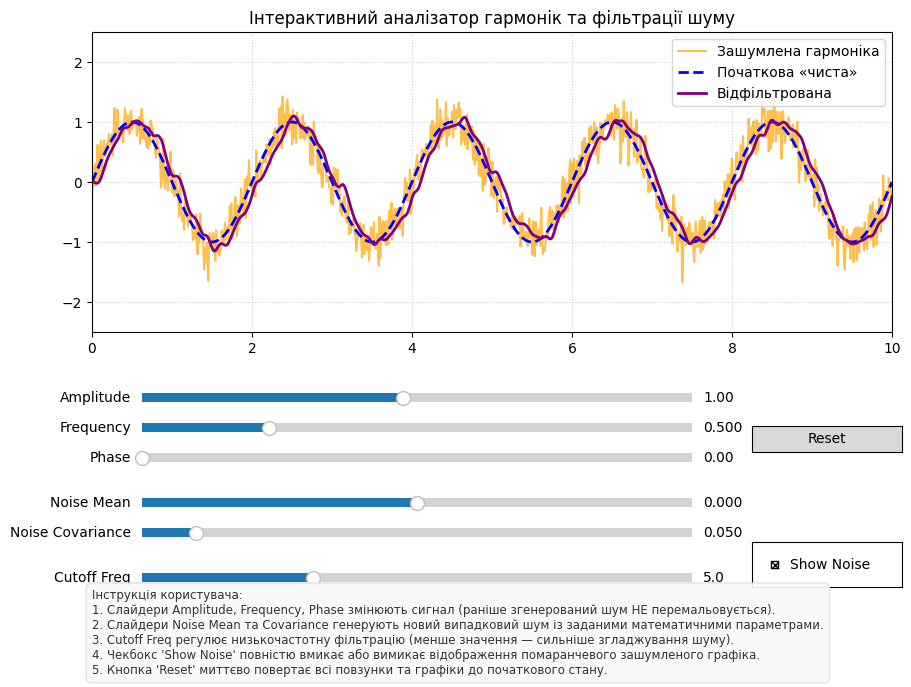

In [2]:
# Початкові параметри системи
init_amp = 1.0
init_freq = 0.5
init_phase = 0.0
init_noise_mean = 0.0
init_noise_cov = 0.05
init_cutoff = 5.0

t_init = np.linspace(0, 10, 1000)
current_noise = np.random.normal(init_noise_mean, np.sqrt(init_noise_cov), size=len(t_init))

# Кеш-змінні для відстеження змін у параметрах шуму
last_noise_mean = init_noise_mean
last_noise_cov = init_noise_cov

# Первинний розрахунок
t, y_pure, y_noisy, _ = harmonic_with_noise(
    init_amp, init_freq, init_phase, init_noise_mean, init_noise_cov, True, current_noise)
y_filtered = filter_signal(y_noisy, init_cutoff)

# Створення графічного вікна
fig, ax = plt.subplots(figsize=(10, 7.5))
plt.subplots_adjust(left=0.1, bottom=0.48)

line_noisy, = ax.plot(t, y_noisy, color='orange', alpha=0.7, label='Зашумлена гармоніка')
line_pure, = ax.plot(t, y_pure, color='blue', linestyle='--', linewidth=2, label='Початкова «чиста»')
line_filtered, = ax.plot(t, y_filtered, color='purple', linewidth=2, label='Відфільтрована')

ax.set_xlim(0, 10)
ax.set_ylim(-2.5, 2.5)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')
ax.set_title("Інтерактивний аналізатор гармонік та фільтрації шуму", fontsize=12)

# Створення осей для слайдерів (координати: [left, bottom, width, height])
ax_amp = plt.axes([0.15, 0.38, 0.55, 0.025])
ax_freq = plt.axes([0.15, 0.34, 0.55, 0.025])
ax_phase = plt.axes([0.15, 0.30, 0.55, 0.025])
ax_n_mean = plt.axes([0.15, 0.24, 0.55, 0.025])
ax_n_cov = plt.axes([0.15, 0.20, 0.55, 0.025])
ax_cutoff = plt.axes([0.15, 0.14, 0.55, 0.025])

s_amp = Slider(ax_amp, 'Amplitude', 0.1, 2.0, valinit=init_amp, valfmt='%1.2f')
s_freq = Slider(ax_freq, 'Frequency', 0.05, 2.0, valinit=init_freq, valfmt='%1.3f')
s_phase = Slider(ax_phase, 'Phase', 0.0, 2*np.pi, valinit=init_phase, valfmt='%1.2f')
s_n_mean = Slider(ax_n_mean, 'Noise Mean', -0.5, 0.5, valinit=init_noise_mean, valfmt='%1.3f')
s_n_cov = Slider(ax_n_cov, 'Noise Covariance', 0.001, 0.5, valinit=init_noise_cov, valfmt='%1.3f')
s_cutoff = Slider(ax_cutoff, 'Cutoff Freq', 0.5, 15.0, valinit=init_cutoff, valfmt='%1.1f')

ax_check = plt.axes([0.76, 0.14, 0.15, 0.06])
check = CheckButtons(ax_check, ['Show Noise'], [True])

ax_reset = plt.axes([0.76, 0.32, 0.15, 0.035])
btn_reset = Button(ax_reset, 'Reset', hovercolor='0.975')

# Додавання текстової інструкції користувача
instruction_text = (
    "Інструкція користувача:\n"
    "1. Слайдери Amplitude, Frequency, Phase змінюють сигнал (раніше згенерований шум НЕ перемальовується).\n"
    "2. Слайдери Noise Mean та Covariance генерують новий випадковий шум із заданими математичними параметрами.\n"
    "3. Cutoff Freq регулює низькочастотну фільтрацію (менше значення — сильніше згладжування шуму).\n"
    "4. Чекбокс 'Show Noise' повністю вмикає або вимикає відображення помаранчевого зашумленого графіка.\n"
    "5. Кнопка 'Reset' миттєво повертає всі повзунки та графіки до початкового стану."
)
fig.text(0.1, 0.02, instruction_text, fontsize=8.5, color='#333333', ha='left', va='bottom',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f9f9f9', edgecolor='#e0e0e0', alpha=0.9))

# Обробник оновлення графіків
def update(val):
    global current_noise, last_noise_mean, last_noise_cov
    
    amp = s_amp.val
    freq = s_freq.val
    phase = s_phase.val
    n_mean = s_n_mean.val
    n_cov = s_n_cov.val
    cutoff = s_cutoff.val
    show_noise = check.get_status()[0]
    
    # Перевірка: якщо параметри шуму не змінилися, використовуємо старий масив шуму
    if n_mean != last_noise_mean or n_cov != last_noise_cov:
        last_noise_mean = n_mean
        last_noise_cov = n_cov
        _, y_p, y_n, current_noise = harmonic_with_noise(amp, freq, phase, n_mean, n_cov, show_noise, global_noise=None)
    else:
        _, y_p, y_n, current_noise = harmonic_with_noise(amp, freq, phase, n_mean, n_cov, show_noise, global_noise=current_noise)
    
    y_f = filter_signal(y_n, cutoff)
    
    line_pure.set_ydata(y_p)
    line_noisy.set_ydata(y_n)
    line_filtered.set_ydata(y_f)
    
    # Динамічне масштабування по осі Y для запобігання виходу ліній за межі екрана
    ax.set_ylim(-amp - np.max(np.abs(current_noise)) - 0.2, amp + np.max(np.abs(current_noise)) + 0.2)
    fig.canvas.draw_idle()

# Зв'язування подій слайдерів з обробником
s_amp.on_changed(update)
s_freq.on_changed(update)
s_phase.on_changed(update)
s_n_mean.on_changed(update)
s_n_cov.on_changed(update)
s_cutoff.on_changed(update)

def update_checkbox(label):
    update(None)
check.on_clicked(update_checkbox)

# Обробник кнопки Reset
def reset_sliders(event):
    global current_noise, last_noise_mean, last_noise_cov
    s_amp.reset()
    s_freq.reset()
    s_phase.reset()
    s_n_mean.reset()
    s_n_cov.reset()
    s_cutoff.reset()
    last_noise_mean = init_noise_mean
    last_noise_cov = init_noise_cov
    current_noise = np.random.normal(init_noise_mean, np.sqrt(init_noise_cov), size=len(t_init))
    if not check.get_status()[0]:
        check.set_active(0)
    update(None)

btn_reset.on_clicked(reset_sliders)
plt.show()